
<a href="https://www.zero-grad.com/">
         <img alt="Zero Grad" src="https://i.postimg.cc/vBPDms4J/pythonml-2.png" >
      </a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
import plotly.express as px
import plotly.io as pio
pio.templates.default = "presentation"

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [8]:
# Reading the data
import pandas as pd

df = pd.read_csv('Bike-Sharing-Dataset/day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


| Feature   | Description                                                                                                |
|-----------|------------------------------------------------------------------------------------------------------------|
| instant   | A unique sequential ID number for each row in the dataset.                                                 |
| dteday    | The date of the rentals, in yyyy-mm-dd format.                                                             |
| season    | A categorical variable indicating the season (1 = spring, 2 = summer, 3 = fall, 4 = winter).               |
| yr        | A categorical variable indicating the year (0 = 2011, 1 = 2012).                                           |
| mnth      | A categorical variable indicating the month of the year (1 to 12).                                         |
| holiday   | A binary variable indicating whether or not the day was a holiday.                                         |
| weekday   | A categorical variable indicating the day of the week (0 = Sunday, 1 = Monday, ..., 6 = Saturday).         |
| workingday| A binary variable indicating whether or not the day was a working day (not a weekend or holiday).          |
| weathersit| A categorical variable indicating the weather situation on the day of rentals.<br> (1 = clear, few clouds, 2 = misty, cloudy, 3 = light snow, light rain, 4 = heavy rain, snow, fog).                          |
| temp      | The actual temperature in Celsius.                                                                         |
| atemp     | The "feels like" temperature in Celsius.                                                                   |
| hum       | The relative humidity.                                                                                    |
| windspeed | The wind speed in km/h.                                                                                    |
| casual    | The number of rentals by casual users.                                                                     |
| registered| The number of rentals by registered users.                                                                 |
| cnt       | The total number of rentals (casual + registered).                                                         |


"Temp" refers to the actual temperature in Celsius, while "atemp" refers to the "feels like" temperature in Celsius. The "feels like" temperature takes into account not only the actual temperature, but also other weather factors such as wind speed and humidity.

So, for example, if the temperature is 20°C but there is a strong wind and low humidity, the "feels like" temperature (i.e., "atemp") might be lower than 20°C because the wind and low humidity can make it feel cooler to a person. Conversely, if the temperature is 20°C and there is no wind or high humidity, the "feels like" temperature (i.e., "atemp") might be higher than 20°C because the lack of wind and high humidity can make it feel warmer to a person.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [10]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [11]:
# plot time series
fig = px.line(df, x='dteday', y='cnt', title='Bike Sharing Demand')
fig.show()

In [12]:
# Cnt per season
fig = px.bar(df, x='season', y='cnt', title='Bike Sharing Demand per Season', width=800)
fig.show()

In [13]:
# Cnt per weekday
fig = px.bar(df, x='weekday', y='cnt', title='Bike Sharing Demand per Weekday', width=800)
fig.show()

In [14]:
# Cnt per workingday
fig = px.bar(df, x='workingday', y='cnt', title='Bike Sharing Demand per Workingday', width=800)
fig.show()

In [15]:
# Cnt per weathersit
fig = px.bar(df, x='weathersit', y='cnt', title='Bike Sharing Demand per Weathersit', width=800)
fig.show()

In [16]:
# Cnt per holiday
fig = px.bar(df, x='holiday', y='cnt', title='Bike Sharing Demand per Holiday', width=800)
fig.show()

In [17]:
# Cnt per mnth
fig = px.bar(df, x='mnth', y='cnt', title='Bike Sharing Demand per Month', width=800)
fig.show()

In [18]:
# Cnt per yr
fig = px.bar(df, x='yr', y='cnt', title='Bike Sharing Demand per Year', width=800)
fig.show()

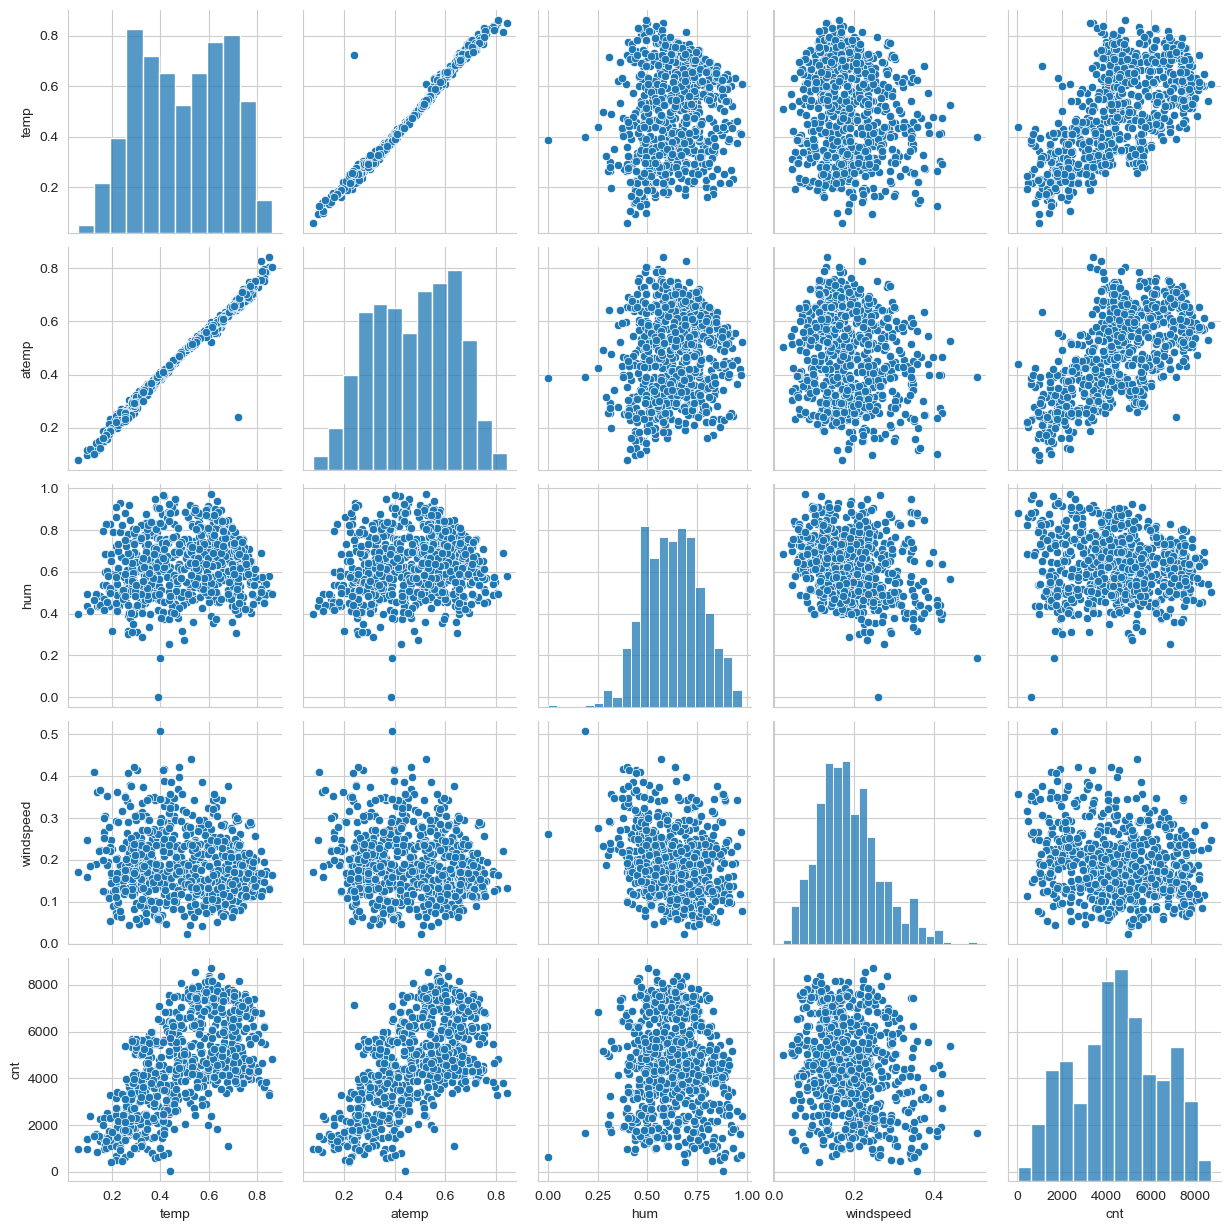

In [19]:
sns.pairplot(df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']])

In [20]:
X = df.drop(['cnt', 'instant', 'dteday', 'casual', 'registered'], axis=1)
y = df['cnt']

In [21]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
# Define the KNN regressor and the parameter grid for hyperparameter tuning
knn = KNeighborsRegressor()
param_grid = {'n_neighbors': np.arange(1, 21)}

# Apply GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)

# Get the best hyperparameters and the corresponding model
best_params = grid_search.best_params_
best_knn = grid_search.best_estimator_

# Evaluate the model on the test set
y_pred = best_knn.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"KNN Regression MSE: {mse:.2f}")
print(f"Best parameters: {best_params}")
print (f"Best score: {grid_search.best_score_}")
print("Train set score: {:.2f}".format(grid_search.score(X_train_scaled, y_train)))
print("Test set score: {:.2f}".format(grid_search.score(X_test_scaled, y_test)))

KNN Regression MSE: 679187.12
Best parameters: {'n_neighbors': 5}
Best score: 0.814452800618205
Train set score: 0.88
Test set score: 0.83


In [23]:
grid = pd.DataFrame(grid_search.cv_results_)
px.line(grid, x='param_n_neighbors', y='mean_test_score', title='KNN Regressor',width=800, height=600, markers=True)

In [24]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred = lin_reg.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
print(f"Linear Regression MSE: {mse:.2f}")

acc = lin_reg.score(X_test_scaled, y_test)
print(f"Linear Regression Accuracy: {acc:.2f}")

Linear Regression MSE: 691035.01
Linear Regression Accuracy: 0.83


# Multi Output Regression

In [25]:
X = df.drop(['instant', 'dteday', 'casual', 'registered', 'cnt'], axis=1)
y = df[['casual', 'registered']]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
# Fit Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predict on test set
y_pred_linear = lin_reg.predict(X_test)

# Calculate and print metrics for Linear Regression
print("Linear Regression metrics:")
print("MSE: ", mean_squared_error(y_test, y_pred_linear))
print("R-squared: ", r2_score(y_test, y_pred_linear))

Linear Regression metrics:
MSE:  301313.13441611436
R-squared:  0.7616014902515543


In [27]:
lin_reg_pred = pd.DataFrame(y_pred_linear, columns=['casual', 'registered'])
lin_reg_pred.head()

,casual,registered
0,719.663927,5500.752685
1,-145.761598,1717.367361
2,114.506295,2929.460733
3,1258.408303,3048.794181
4,933.553452,5832.105620


In [28]:
# Fit Ridge Regression model
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=10)
ridge_reg.fit(X_train, y_train)

# Predict on test set
y_pred_ridge = ridge_reg.predict(X_test)

# Calculate and print metrics for Ridge Regression
print("Ridge Regression metrics:")
print("MSE: ", mean_squared_error(y_test, y_pred_ridge))
print("R-squared: ", r2_score(y_test, y_pred_ridge))

Ridge Regression metrics:
MSE:  336831.33481457795
R-squared:  0.7399693913214697


In [29]:
ridge_reg_pred = pd.DataFrame(y_pred_ridge, columns=['casual', 'registered'])
ridge_reg_pred.head()

,casual,registered
0,842.635571,5552.491275
1,24.703457,1993.580112
2,250.552016,3152.554318
3,1178.424253,3021.870399
4,1010.497797,5810.003955


In [30]:
# Fit KNN Regression model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict on test set
y_pred_knn = knn.predict(X_test)

# Calculate and print metrics for KNN Regression
print("KNN Regression metrics:")
print("MSE: ", mean_squared_error(y_test, y_pred_knn))
print("R-squared: ", r2_score(y_test, y_pred_knn))

KNN Regression metrics:
MSE:  409825.5276190473
R-squared:  0.7352188986983146


In [31]:
knn_pred = pd.DataFrame(y_pred_knn, columns=['casual', 'registered'])
knn_pred.head()

,casual,registered
0,346.6,4664.4
1,123.2,1646.8
2,703.4,3984.2
3,1476.4,2678.8
4,897.4,6575.4
